# Dataset Import and Initial Analysis

In [ ]:
#Importing libraries for our purpose
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('aerofit.csv')

In [ ]:
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
#length of data
len(df)

180

In [ ]:
#checking datatypes
df.dtypes

,0
Product,object
Age,int64
Gender,object
Education,int64
MaritalStatus,object
Usage,int64
Fitness,int64
Income,int64
Miles,int64


In [ ]:
#number of unique values in our data
for i in df.columns:
    print(i,len(df[i].unique()))

Product 3
Age 32
Gender 2
Education 8
MaritalStatus 2
Usage 6
Fitness 5
Income 62
Miles 37


In [ ]:
#checking null values in every column of our data
df.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


# Detect Outliers and Clip Data

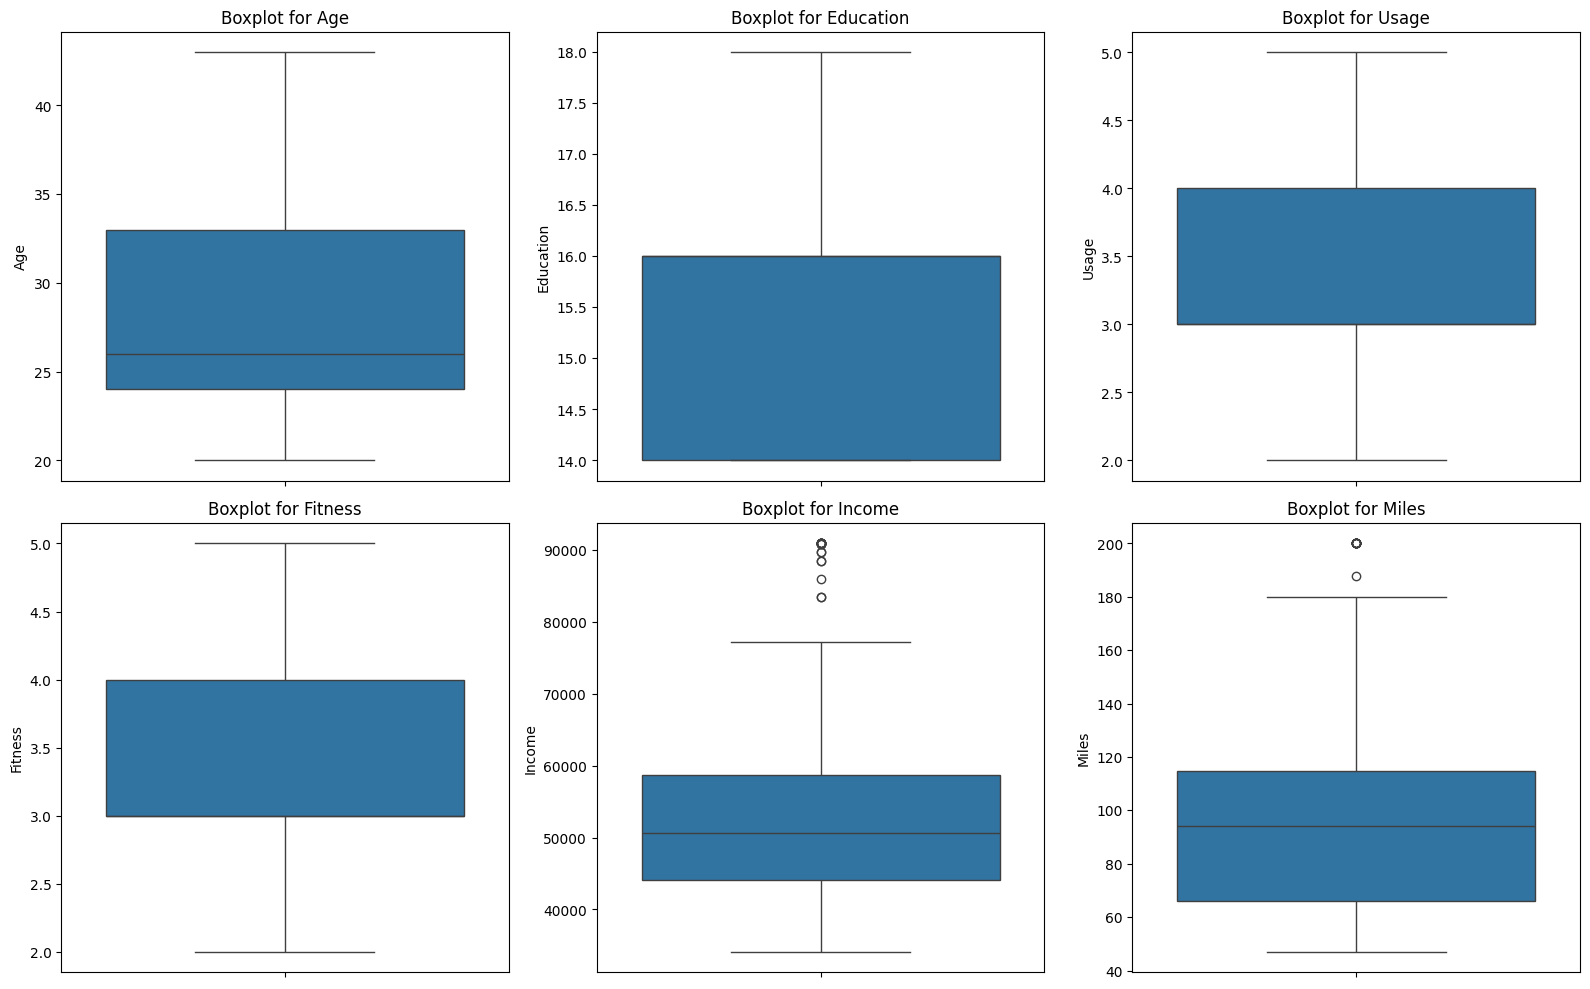


Outlier Clipped Summary:
              Age   Education       Usage     Fitness        Income  \
count  180.000000  180.000000  180.000000  180.000000    180.000000   
mean    28.638895   15.572222    3.394451    3.322222  53476.800675   
std      6.440774    1.362017    0.948383    0.937461  15452.523257   
min     20.000000   14.000000    2.000000    2.000000  34109.857875   
25%     24.000000   14.000000    3.000000    3.000000  44058.750000   
50%     26.000000   16.000000    3.000000    3.000000  50596.500000   
75%     33.000000   16.000000    4.000000    4.000000  58668.000000   
max     43.000125   18.000000    5.000125    5.000000  90886.155625   

            Miles  
count  180.000000  
mean   101.088889  
std     43.364286  
min     47.000000  
25%     66.000000  
50%     94.000000  
75%    114.750000  
max    200.000000  


In [ ]:
# Continuous Variables
continuous_columns = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']

# Boxplots for Outliers
plt.figure(figsize=(16, 10))
for i, column in enumerate(continuous_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df[column])
    plt.title(f'Boxplot for {column}')
plt.tight_layout()
plt.show()

# Clipping Data
for column in continuous_columns:
    lower_bound = df[column].quantile(0.05)
    upper_bound = df[column].quantile(0.95)
    df[column] = np.clip(df[column], lower_bound, upper_bound)

# Verify Clipping
print("\nOutlier Clipped Summary:")
print(df[continuous_columns].describe())

Age: The median age of customers is around 28 years old. There are no outliers.

Education: The median education level of customers is around 16 years. There are no outliers.

Usage: The median usage of the product is around 3.5. There are no outliers.

Fitness: The median fitness level is around 3.5. There are no outliers.

Income: The median income of customers is around 60,000. There are some outliers on the higher end of the income range.

Miles: The median miles travelled is around 130. There is one outlier above the upper whisker.

# Relationship Analysis

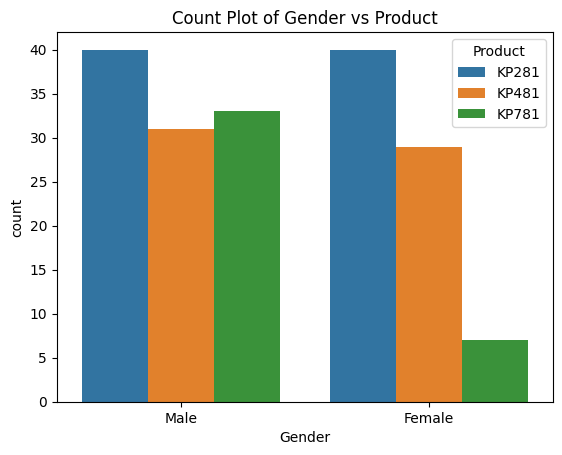

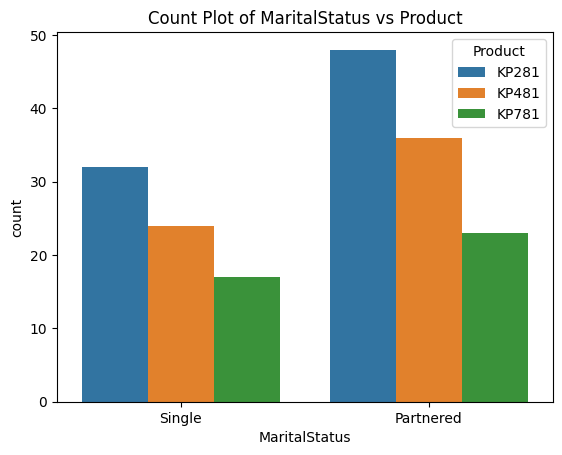

In [ ]:
# Count Plots for Categorical Variables
categorical_columns = ['Gender', 'MaritalStatus']
for column in categorical_columns:
    sns.countplot(data=df, x=column, hue='Product')
    plt.title(f'Count Plot of {column} vs Product')
    plt.show()

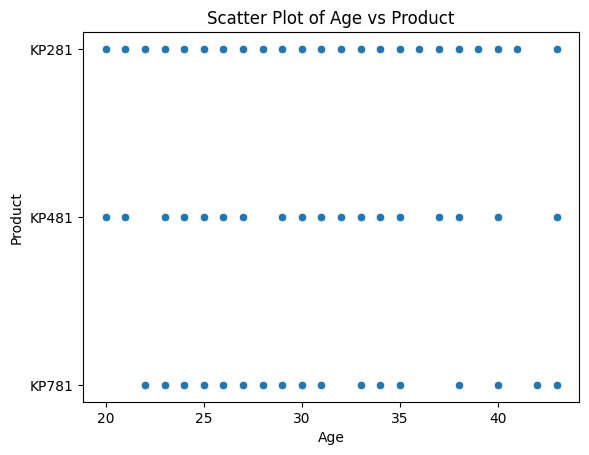

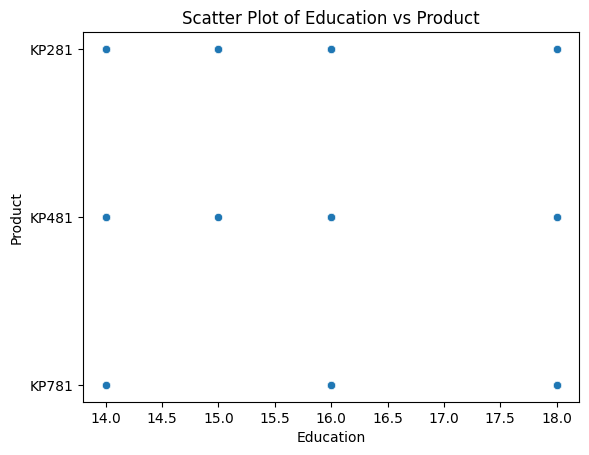

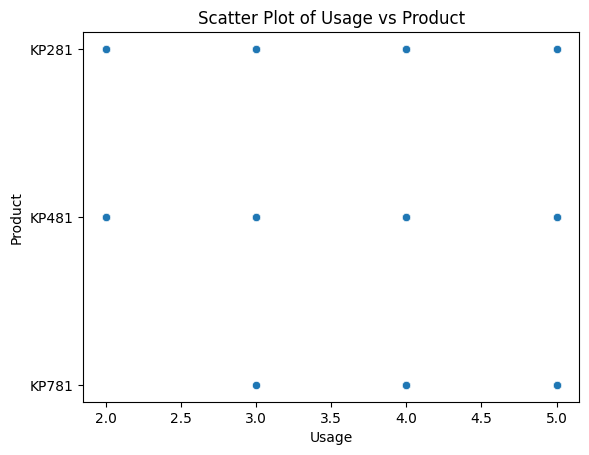

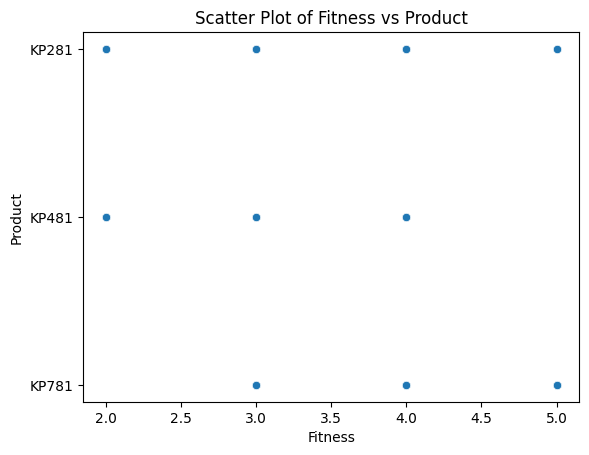

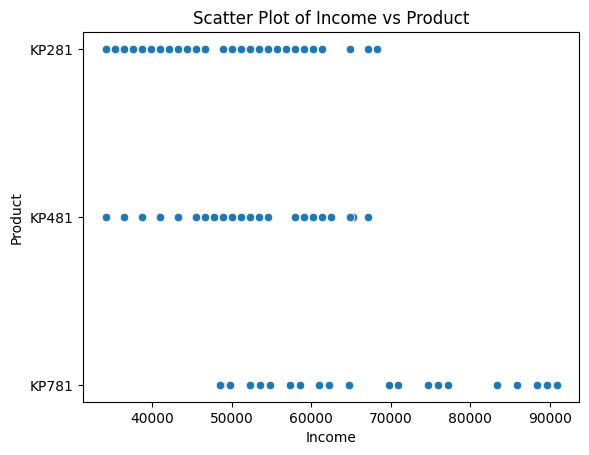

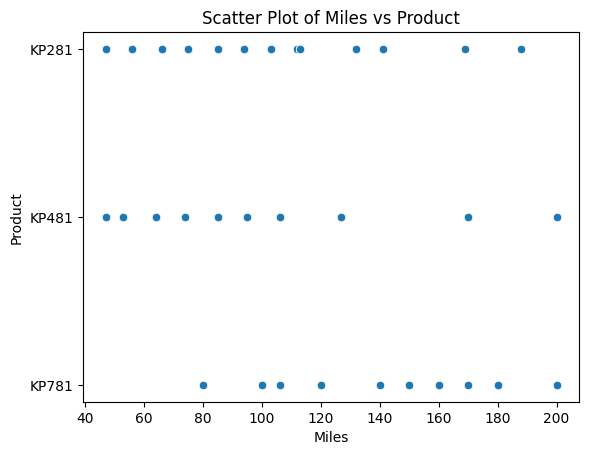

In [ ]:
# Scatter Plots for Continuous Variables
for column in continuous_columns:
    sns.scatterplot(data=df, x=column, y='Product')
    plt.title(f'Scatter Plot of {column} vs Product')
    plt.show()

1. The scatter plot shows a weak relationship between income and product choice.

2. There is a slight tendency for customers with higher incomes to choose the KP281 product.

3. There is no clear distinction between the income levels of customers who choose KP481 and KP781.

# Representing the Probability

In [ ]:
# Marginal Probability
product_counts = df['Product'].value_counts(normalize=True)
print("\nMarginal Probabilities:")
print(product_counts)


Marginal Probabilities:
Product
KP281    0.444444
KP481    0.333333
KP781    0.222222
Name: proportion, dtype: float64


In [ ]:
# Probability by Column
for column in categorical_columns + continuous_columns:
    prob_table = pd.crosstab(df[column], df['Product'], normalize='index')
    print(f"\nProbability Table for {column}:")
    print(prob_table)


Probability Table for Gender:
Product     KP281     KP481     KP781
Gender                               
Female   0.526316  0.381579  0.092105
Male     0.384615  0.298077  0.317308

Probability Table for MaritalStatus:
Product           KP281     KP481     KP781
MaritalStatus                              
Partnered      0.448598  0.336449  0.214953
Single         0.438356  0.328767  0.232877

Probability Table for Age:
Product       KP281     KP481     KP781
Age                                    
20.000000  0.600000  0.400000  0.000000
21.000000  0.571429  0.428571  0.000000
22.000000  0.571429  0.000000  0.428571
23.000000  0.444444  0.388889  0.166667
24.000000  0.416667  0.250000  0.333333
25.000000  0.280000  0.440000  0.280000
26.000000  0.583333  0.250000  0.166667
27.000000  0.428571  0.142857  0.428571
28.000000  0.666667  0.000000  0.333333
29.000000  0.500000  0.166667  0.333333
30.000000  0.285714  0.285714  0.428571
31.000000  0.333333  0.500000  0.166667
32.000000  0.50

In [ ]:
# Example: Conditional Probability for Gender
gender_prob = pd.crosstab(df['Gender'], df['Product'], normalize='index')
print("\nConditional Probability for Gender:")
print(gender_prob)


Conditional Probability for Gender:
Product     KP281     KP481     KP781
Gender                               
Female   0.526316  0.381579  0.092105
Male     0.384615  0.298077  0.317308


# Correlation Among Features

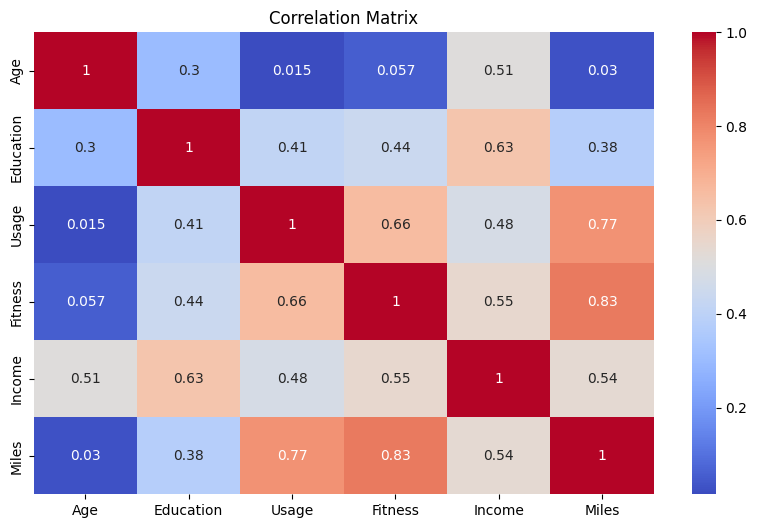

In [ ]:
# Correlation Matrix
correlation_matrix = df[continuous_columns].corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Strong positive correlation:
    
    Between Usage and Fitness (0.66)
    Between Fitness and Income (0.55)
    Between Education and Income (0.63)
    Between Usage and Miles (0.77)
    Between Fitness and Miles (0.83)

Moderate positive correlation:
    
    Between Age and Income (0.51)
    Between Education and Miles (0.38)

Weak positive correlation:
    
    Between Age and Education (0.3)
    Between Usage and Income (0.48)
    Between Education and Usage (0.41)

Very weak correlation:
    
    Between Age and Usage (0.015)
    Between Age and Fitness (0.057)
    Between Age and Miles (0.03)

No correlation:

    Between Income and Miles (0.54)

# Customer Profiling and Recommendation

In [ ]:
# Profiling for Each Product
for product in df['Product'].unique():
    profile = df[df['Product'] == product].describe()
    print(f"\nCustomer Profile for {product}:")
    print(profile)


Customer Profile for KP281:
             Age  Education      Usage    Fitness        Income       Miles
count  80.000000   80.00000  80.000000  80.000000     80.000000   80.000000
mean   28.425006   15.12500   3.087500   2.975000  46588.564341   83.125000
std     6.672791    1.07179   0.782624   0.635948   8807.132972   28.391198
min    20.000000   14.00000   2.000000   2.000000  34109.857875   47.000000
25%    23.000000   14.00000   3.000000   3.000000  38658.000000   66.000000
50%    26.000000   16.00000   3.000000   3.000000  46617.000000   85.000000
75%    33.000000   16.00000   4.000000   3.000000  53439.000000   94.000000
max    43.000125   18.00000   5.000000   5.000000  68220.000000  188.000000

Customer Profile for KP481:
             Age  Education      Usage    Fitness        Income       Miles
count  60.000000  60.000000  60.000000  60.000000     60.000000   60.000000
mean   28.800004  15.183333   3.066667   2.916667  49049.442894   88.500000
std     6.324029   1.112208   

**Detailed Recommendations**

1. KP281 (Entry-Level)

    Target Audience: Young professionals and beginners in fitness with limited disposable income.
  
    Marketing Focus: Highlight affordability, simplicity, and suitability for casual fitness goals.
  
    Sales Channels: Promote through online platforms, targeting tech-savvy younger customers.

2. KP481 (Mid-Level)

    Target Audience: Mid-income professionals or families seeking better features without high costs.
    
    Marketing Focus: Emphasize durability, enhanced features, and value for money.
    
    Sales Channels: Utilize both online and offline channels to reach this demographic.

3. KP781 (Advanced)

    Target Audience: High-income individuals, fitness enthusiasts, and advanced users.

    Marketing Focus: Promote advanced features, premium quality, and superior performance.

    Sales Channels: Focus on premium outlets and fitness centers for direct sales demonstrations.

4. Product Bundling and Promotions:

    Offer beginner kits (e.g., fitness guides, mats) with KP281 to attract first-time buyers.

    Include premium services such as maintenance plans or personal training programs with KP781.

5.  Future Development:
  
    Consider launching a new product bridging the gap between KP481 and KP781 for upper-middle-income customers.

    Introduce compact or portable models of KP281 to appeal to urban customers with limited space.